# 04 Evaluation

Goal:
- Load saved metric table.
- Create report-ready comparison plots.
- Write interpretation notes for BAB IV.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
metrics = pd.read_csv("../reports/tables/model_metrics.csv")
metrics

,model,pr_auc,f1_suspicious,precision_suspicious,recall_suspicious,tp,fp,tn,fn,feature_set
0,lightgbm,0.140712,0.038961,0.600000,0.020134,3,2,99849,146,raw_plus_graph
1,xgboost,0.030983,0.052910,0.125000,0.033557,5,35,99816,144,raw_plus_graph
2,random_forest,0.008568,0.000000,0.000000,0.000000,0,31,99820,149,raw_plus_graph
3,random_forest,0.008011,0.000000,0.000000,0.000000,0,5,99846,149,raw
4,xgboost,0.006216,0.007080,0.004808,0.013423,2,414,99437,147,raw
5,logistic_regression,0.004916,0.010461,0.005317,0.322148,48,8980,90871,101,raw_plus_graph
6,lightgbm,0.002832,0.000000,0.000000,0.000000,0,267,99584,149,raw
7,logistic_regression,0.002790,0.003502,0.001760,0.355705,53,30065,69786,96,raw


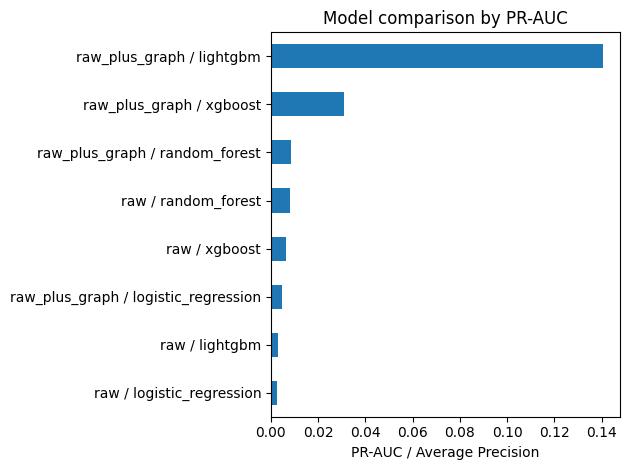

In [3]:
# PR-AUC comparison figure
plot_df = metrics.sort_values("pr_auc", ascending=True)
labels = plot_df["feature_set"] + " / " + plot_df["model"]

ax = plot_df.plot(kind="barh", x=None, y="pr_auc", legend=False)
ax.set_yticklabels(labels)
ax.set_title("Model comparison by PR-AUC")
ax.set_xlabel("PR-AUC / Average Precision")
plt.tight_layout()
Path("../reports/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../reports/figures/model_pr_auc_comparison.png", dpi=150)
plt.show()

## BAB IV interpretation template

Write your interpretation using your actual results:

- Which model has the highest PR-AUC?
- Did graph features improve PR-AUC or suspicious-class F1?
- Was recall improved at the cost of precision?
- Why is accuracy not emphasized?
- What graph features are likely useful?
- What are the false positive / false negative implications for AML analysts?